# Irregular Rigid-Body Collision -- Energy Diagnostics

Loads the per-frame energy logs written by `rigid_body_collision.cpp` for the two simulation runs:

- **elastic**: restitution `e = 1.0`, no air drag (Parts 1-3 baseline)
- **inelastic**: restitution `e = 0.75`, with linear air drag (Part 4)

and checks that the elastic run conserves total mechanical energy across bounces (numerical validation of the closed-form collision response), while the inelastic run visibly loses energy and bounce height over time.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

elastic = pd.read_csv("data/energy_elastic.csv")
inelastic = pd.read_csv("data/energy_inelastic.csv")

elastic.head()

,t,kinetic_energy,potential_energy,total_energy,angular_velocity,com_y
0,0.000000,59.4000,5940.00,5999.4,0.0,45.0000
1,0.033333,62.3333,5937.07,5999.4,0.0,44.9778
2,0.066667,71.1333,5928.27,5999.4,0.0,44.9111
3,0.100000,85.8000,5913.60,5999.4,0.0,44.8000
4,0.133333,106.3330,5893.07,5999.4,0.0,44.6444


Elastic run energy drift: 0.271% (start=5999.4, end=6015.7)
Inelastic run energy loss: 73.2% (start=5999.4, end=1606.1)


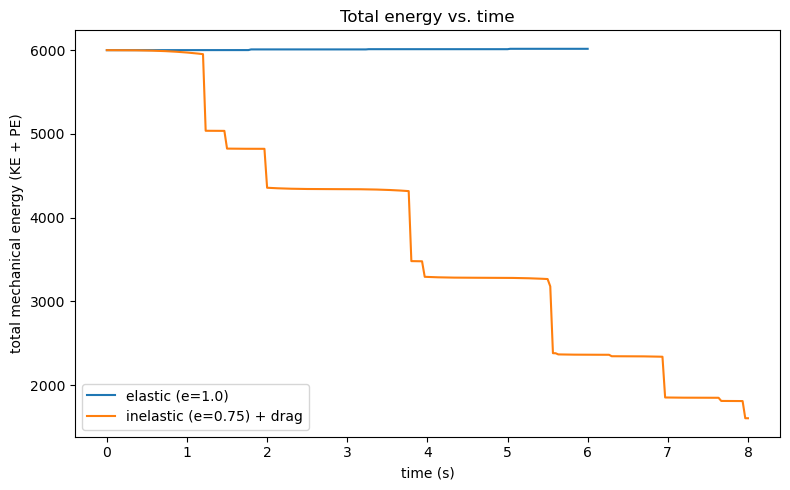

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(elastic["t"], elastic["total_energy"], label="elastic (e=1.0)")
ax.plot(inelastic["t"], inelastic["total_energy"], label="inelastic (e=0.75) + drag")
ax.set_xlabel("time (s)")
ax.set_ylabel("total mechanical energy (KE + PE)")
ax.set_title("Total energy vs. time")
ax.legend()
fig.tight_layout()
fig.savefig("data/energy_vs_time.png", dpi=120)

e0 = elastic["total_energy"].iloc[0]
e1 = elastic["total_energy"].iloc[-1]
drift_pct = 100.0 * abs(e1 - e0) / abs(e0)
print(f"Elastic run energy drift: {drift_pct:.3f}% (start={e0:.1f}, end={e1:.1f})")

i0 = inelastic["total_energy"].iloc[0]
i1 = inelastic["total_energy"].iloc[-1]
loss_pct = 100.0 * (i0 - i1) / abs(i0)
print(f"Inelastic run energy loss: {loss_pct:.1f}% (start={i0:.1f}, end={i1:.1f})")

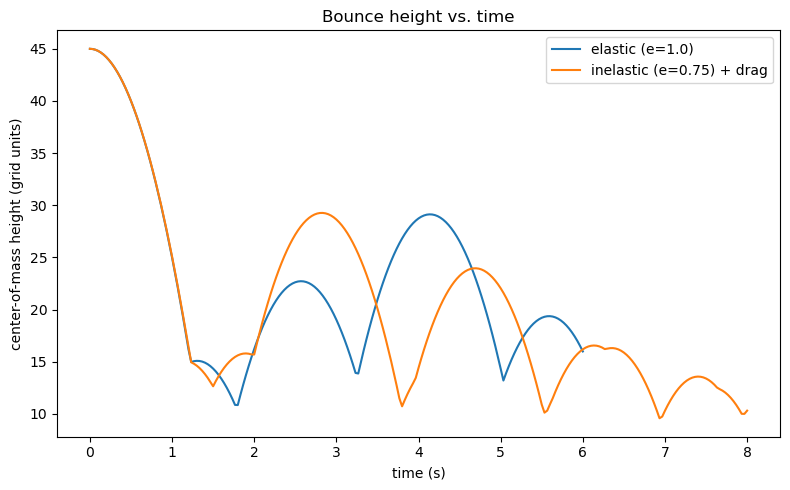

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(elastic["t"], elastic["com_y"], label="elastic (e=1.0)")
ax.plot(inelastic["t"], inelastic["com_y"], label="inelastic (e=0.75) + drag")
ax.set_xlabel("time (s)")
ax.set_ylabel("center-of-mass height (grid units)")
ax.set_title("Bounce height vs. time")
ax.legend()
fig.tight_layout()
fig.savefig("data/bounce_height_vs_time.png", dpi=120)

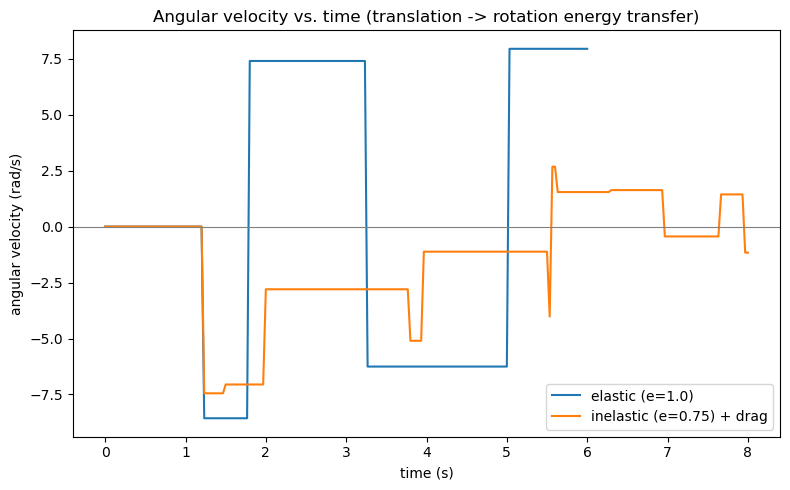

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(elastic["t"], elastic["angular_velocity"], label="elastic (e=1.0)")
ax.plot(inelastic["t"], inelastic["angular_velocity"], label="inelastic (e=0.75) + drag")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("time (s)")
ax.set_ylabel("angular velocity (rad/s)")
ax.set_title("Angular velocity vs. time (translation -> rotation energy transfer)")
ax.legend()
fig.tight_layout()
fig.savefig("data/angular_velocity_vs_time.png", dpi=120)

The body starts with zero angular velocity; each off-center bounce (the shape's center of mass is not at its geometric center) kicks it into rotation, which is exactly the translation-to-rotation energy exchange the closed-form collision response (Eqs. 10-11) is designed to produce.